# COMPARE HSP2 TO HSPF USING CALLEG

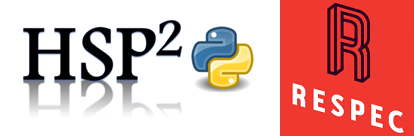

Copyright 2020 for this Jupyter Notebook and YouTube Video by RESPEC, INC.  All rights reserved.

$\textbf{HSP}^{\textbf{2}}\ \text{and}\ \textbf{HSP2}\ $ Copyright 2020 by RESPEC INC. and released under the *GNU AFFERO GENERAL PUBLIC LICENSE*

This Notebook will compare the results of running HSPF and HSP$^2$ for the basic hydrology (PWATER, IWATER, and HYDR) to confirm the proper calculations of HSP$^2$

Calleg is a real watershed and has
+ 27 IMPLND segments,
+ 129 PERLND segments,
+ 119 RCHRES segments,
+ 9 years of simulation time with hourly time steps (78,888 timesteps) from 1993-10-01 to 2002-10-01

This Notebook assumes HSPF has been run and the HBN data saved to an HDF5 file in the **HSPF RUN** directory.

## Required Python imports  and setup

In [1]:
import os

import pandas as pd
from matplotlib import pyplot as plt

# Set display options for convenience, does't change the data
pd.options.display.max_rows = 150
pd.options.display.max_columns = 20
pd.options.display.float_format = (
    "{:.4f}".format
)  # display 4 digits after the decimal point

%matplotlib inline

from hsp2.hsp2 import main, versions
from hsp2.hsp2tools import readUCI, readWDM

versions(["matplotlib"])

,version
name,
Python,"3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11...."
hsp2,0.11.0a1
numpy,1.26.4
numba,0.64.0
pandas,2.3.3
matplotlib,3.10.8
os,Linux-6.19.12-200.fc43.x86_64-x86_64-with-glib...
processor,
Date/Time,2026-05-06T21:46:18.717082


Convenient name strings to get to the data

In [2]:
wdmname = "TEST.WDM"
uciname = "TEST05.UCI"
HBN = "hspf.h5"
hdfname = "hsp2.h5"

## Run HSP2 on the calleg

### Create HDF5 file

In [3]:
readUCI(uciname, hdfname)
readWDM(wdmname, hdfname)

/tmp/ipykernel_40492/3398803723.py:1: DeprecationWarning: Call to deprecated function readUCI (

readUCI is deprecated and will be removed in a future release.
Use hsp2.hsp2io.control_file_readers.read_uci_parameters to read the parameters.

).
  readUCI(uciname, hdfname)
/var/home/timcera/miniconda3/envs/default311/lib/python3.11/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: 'CURV-DATA1'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/var/home/timcera/miniconda3/envs/default311/lib/python3.11/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: 'CURV-DATA2'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_at

39 reading from wdm
41 reading from wdm
42 reading from wdm
46 reading from wdm
113 reading from wdm
119 reading from wdm
121 reading from wdm
122 reading from wdm
123 reading from wdm
124 reading from wdm
125 reading from wdm
126 reading from wdm
127 reading from wdm
131 reading from wdm
132 reading from wdm
134 reading from wdm
135 reading from wdm
136 reading from wdm
140 reading from wdm


### Run

Using profiler

Normal run

In [4]:
main(hdfname, saveall=True)

2026-05-06 21:46:22.32   Processing started for file hsp2.h5; saveall=True
Skipping un-typed siminfo
op_tokens has 20 elements, with  1 executable elements
2026-05-06 21:46:25.29   Simulation Start: 1976-01-01 00:00:00, Stop: 1977-01-01 00:00:00
2026-05-06 21:46:25.29      PERLND P001 DELT(minutes): 30
2026-05-06 21:46:25.64         SNOW
2026-05-06 21:46:26.33         PWATER
2026-05-06 21:46:26.71      PERLND P002 DELT(minutes): 30
2026-05-06 21:46:26.71         SNOW
2026-05-06 21:46:26.81         PWATER
2026-05-06 21:46:26.96      PERLND P003 DELT(minutes): 30
2026-05-06 21:46:26.98         SNOW
2026-05-06 21:46:27.08         PWATER
2026-05-06 21:46:27.24      COPY COPY001 DELT(minutes): 30
2026-05-06 21:46:27.24      COPY COPY002 DELT(minutes): 30
2026-05-06 21:46:27.24      COPY COPY003 DELT(minutes): 30
2026-05-06 21:46:27.24      DISPLY D001 DELT(minutes): 30
2026-05-06 21:46:27.24      PLTGEN L001 DELT(minutes): 30
2026-05-06 21:46:27.24   Done; Run time is about 00:04.9 (mm:ss)


## Read Summary from HBN file

Find the higest frequency data available.

In [5]:
summary = pd.read_hdf(HBN, "SUMMARY")
summary.Frequency.unique()

array(['Monthly', 'Yearly'], dtype=object)

So the best available is monthly data.

## Automate checking by output flow

In [6]:
def hsp2key(hspfkey):
    op, activity, segment, _ = hspfkey.split("_")
    return f"/RESULTS/{op}_{op[0]}{segment:0>3s}/{activity}"

In [18]:
def monthlyoutflow(keys, flowname, how="sum"):
    concat = []
    for key in keys.index:
        hsp2 = (
            pd.read_hdf(hdfname, hsp2key(key))[flowname].resample("ME").sum().to_numpy()
        )[:-1]
        
        hspf_flowname = flowname.split("_")[0]
        hspf = pd.read_hdf(HBN, key)[hspf_flowname].to_numpy()

        hsp2sum = hsp2.sum()
        hspfsum = hspf.sum()

        segment = key.split("_")[2]

        data = pd.DataFrame(index=[segment])
        data["HSP2_SUM"] = hsp2sum
        data["HSPF_SUM"] = hspfsum
        data["Percent diff"] = 100 * (hspfsum - hsp2sum) / hspfsum
        data["abs(Percent diff)"] = 100 * abs(hspfsum - hsp2sum) / hspfsum

        concat.append(data)

    return pd.concat(concat).sort_values(by=["abs(Percent diff)"])

### Define a function to plot HSPF and HSP2 data

In [27]:
def plot(operation, ils, activity, name, how="sum"):
    hspf = f"{operation}_{activity}_{ils:0>3s}_4"
    hspf_flowname = name.split("_")[0]
    tshspf = pd.read_hdf(HBN, hspf)[hspf_flowname]

    hsp2 = f"RESULTS/{operation}_{operation[0]}{ils:0>3s}/{activity}"
    if how == "sum":
        tshsp2 = (
            pd.read_hdf(hdfname, hsp2)[f"{name}"]
            .resample("ME")
            .sum()
            .shift(1, "D")
        )[:-1]
    elif how == "last":
        tshsp2 = (
            pd.read_hdf(hdfname, hsp2)[f"{name}"]
            .resample("ME")
            .last()
            .shift(1, "D")
        )[:-1]

    plt.figure(figsize=(10, 8))
    plt.plot(tshspf.index, tshspf, label="HSPF", color="salmon", lw=4)
    plt.plot(tshsp2.index, tshsp2, label="HSP2", color="b", lw=1, linestyle="dashed")
    plt.legend()
    plt.title(f"{operation} {operation[0]}{ils:0>3s}, {activity} {name}")

In [28]:
def scatter(operation, ils, activity, name, how="sum"):
    hspf = f"{operation}_{activity}_{ils:0>3s}_4"
    tshspf = pd.read_hdf(HBN, hspf)[name]

    hsp2 = f"RESULTS/{operation}_{operation[0]}{ils:0>3s}/{activity}"
    if how == "sum":
        tshsp2 = (
            pd.read_hdf(hdfname, hsp2)[name]
            .resample("ME")
            .sum()
            .shift(1, "D")
        )[:-1]
    elif how == "last":
        tshsp2 = (
            pd.read_hdf(hdfname, hsp2)[name]
            .resample("ME")
            .last()
            .shift(1, "D")
        )[:-1]
        
    plt.scatter(tshspf, tshsp2)

## Automate checking PERLNDs for PERO

In [29]:
perlndkeys = summary[(summary.Frequency == "Monthly") & (summary.Operation == "PERLND") & (summary.Activity == "PWATER")]
perlndkeys[0:10]

,Operation,Activity,segment,Frequency,Shape,Start,Stop
PERLND_PWATER_001_4,PERLND,PWATER,1,Monthly,"(12, 29)",1976-02-01,1977-01-01
PERLND_PWATER_002_4,PERLND,PWATER,2,Monthly,"(12, 29)",1976-02-01,1977-01-01
PERLND_PWATER_003_4,PERLND,PWATER,3,Monthly,"(12, 29)",1976-02-01,1977-01-01


In [30]:
delta = monthlyoutflow(perlndkeys, "PERO")
delta

,HSP2_SUM,HSPF_SUM,Percent diff,abs(Percent diff)
003,4.3364,4.3411,0.1097,0.1097
002,4.3414,4.3356,-0.1333,0.1333
001,4.4461,4.4386,-0.1686,0.1686


Look at the statistics for the percent difference column

In [31]:
delta.describe()

,HSP2_SUM,HSPF_SUM,Percent diff,abs(Percent diff)
count,3.0000,3.0000,3.0000,3.0000
mean,4.3746,4.3718,-0.0641,0.1372
std,0.0619,0.0579,0.1516,0.0296
min,4.3364,4.3356,-0.1686,0.1097
25%,4.3389,4.3384,-0.1510,0.1215
50%,4.3414,4.3411,-0.1333,0.1333
75%,4.3937,4.3898,-0.0118,0.1510
max,4.4461,4.4386,0.1097,0.1686


<Axes: >

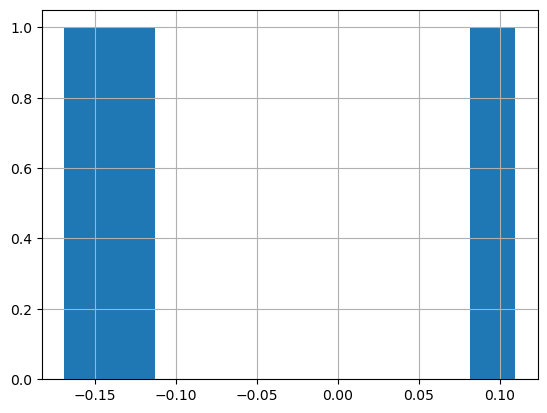

In [32]:
delta["Percent diff"].hist()

In [33]:
pls = delta.index[-1]
print("WORST PERLND SEGMENT IS", pls)

WORST PERLND SEGMENT IS 001


#### PERLND PWATER PERO

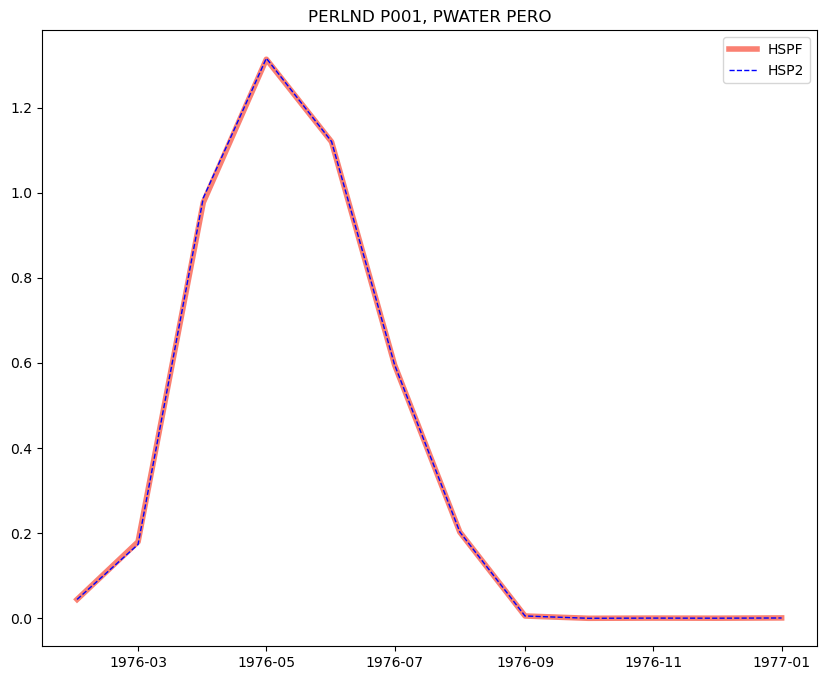

In [34]:
plot("PERLND", pls, "PWATER", "PERO", "sum")

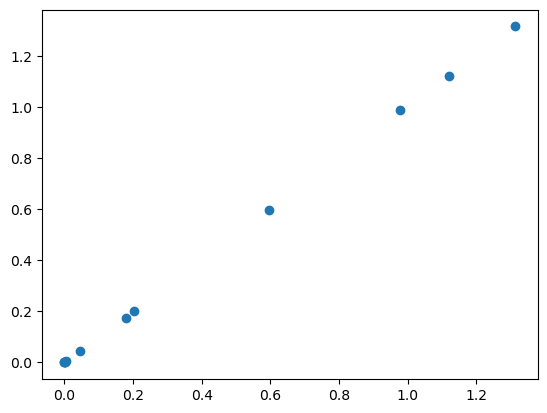

In [35]:
scatter("PERLND", pls, "PWATER", "PERO", "sum")

#### PERLND PWATER AGWO

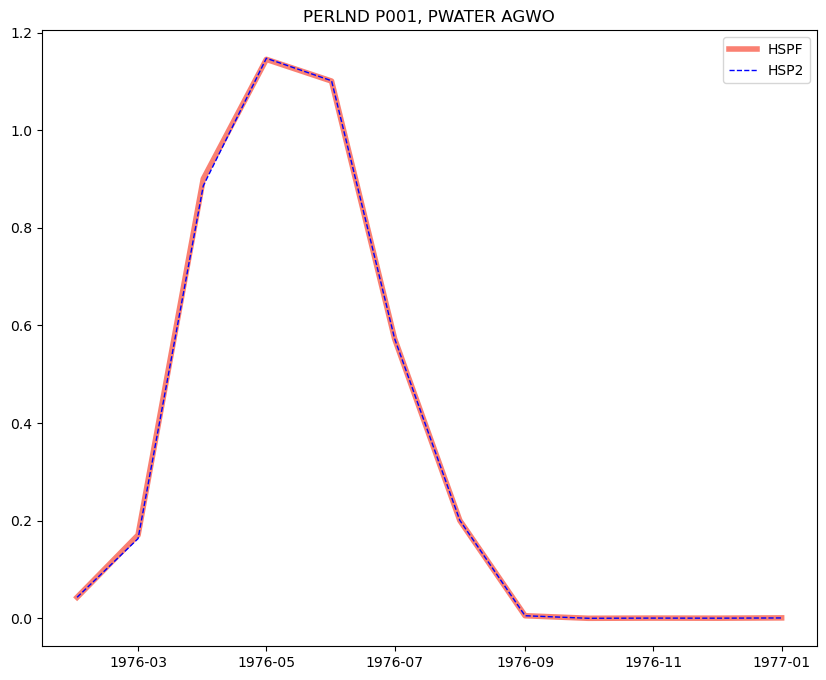

In [37]:
plot("PERLND", pls, "PWATER", "AGWO", "sum")

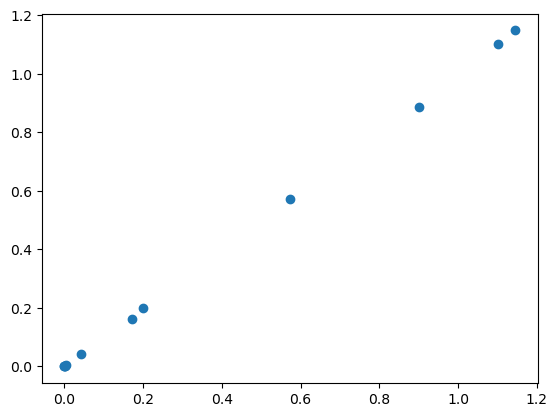

In [38]:
scatter("PERLND", pls, "PWATER", "AGWO", "sum")

#### PERLND PWATER BASET

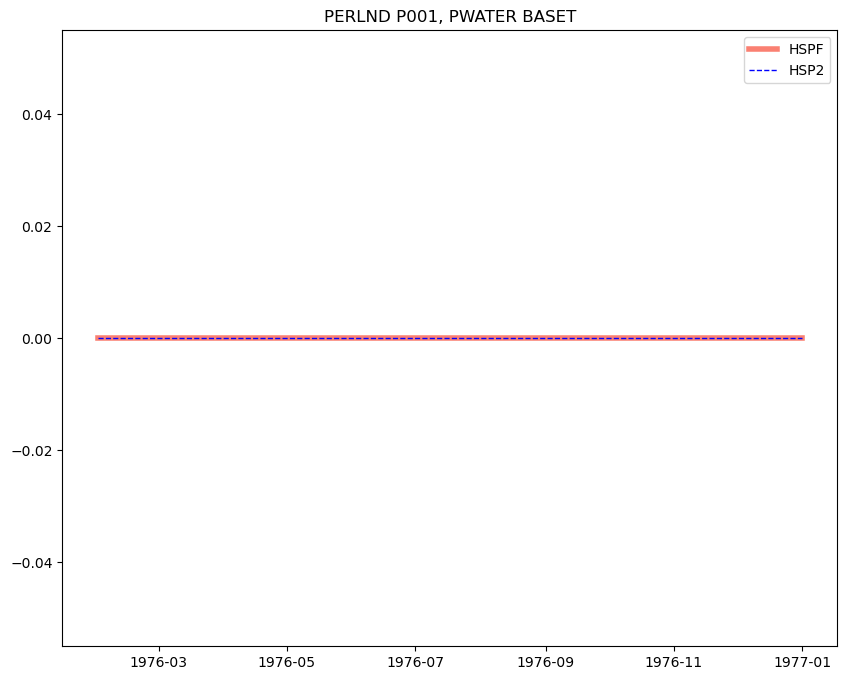

In [39]:
plot("PERLND", pls, "PWATER", "BASET", "sum")

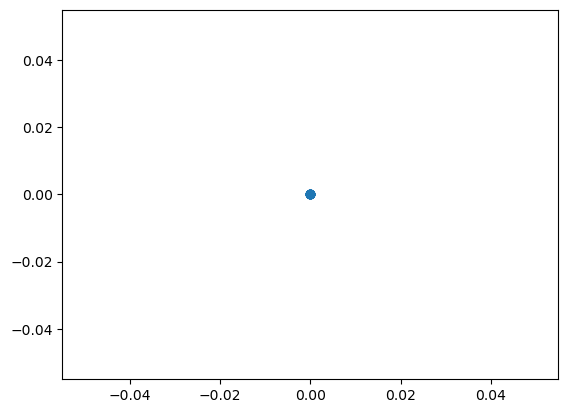

In [40]:
scatter("PERLND", pls, "PWATER", "BASET", "sum")

##### PERLND PWATER CEPE

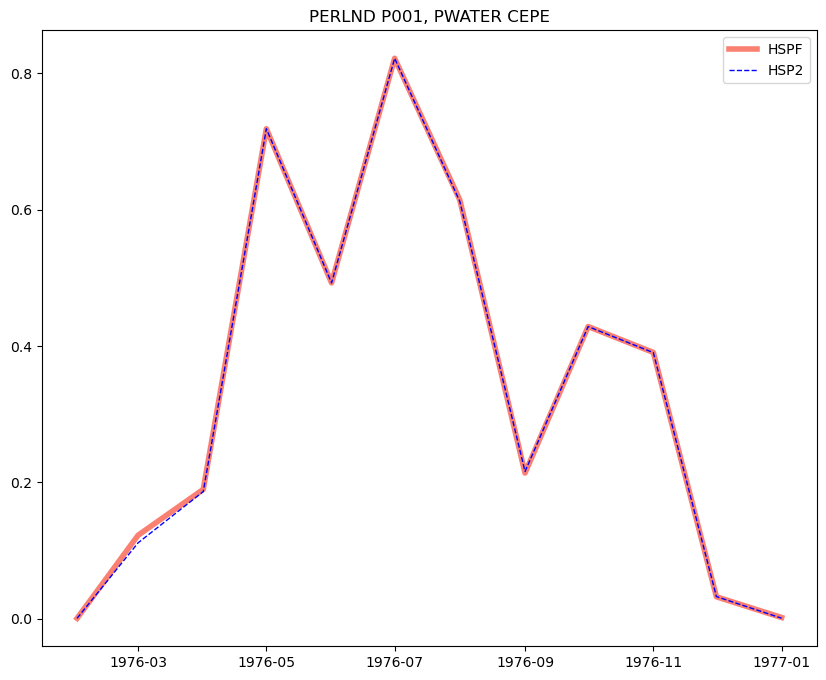

In [41]:
plot("PERLND", pls, "PWATER", "CEPE", "sum")

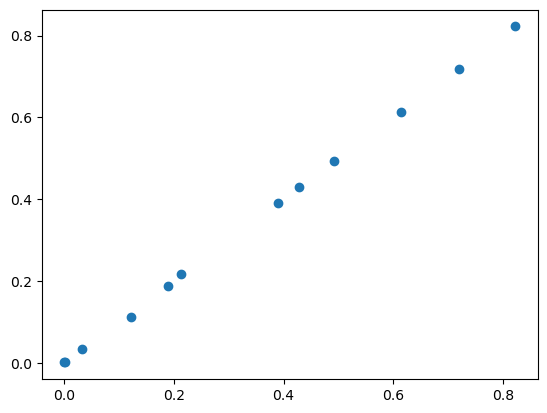

In [42]:
scatter("PERLND", pls, "PWATER", "CEPE", "sum")

#### PERLND PWATER IFWI

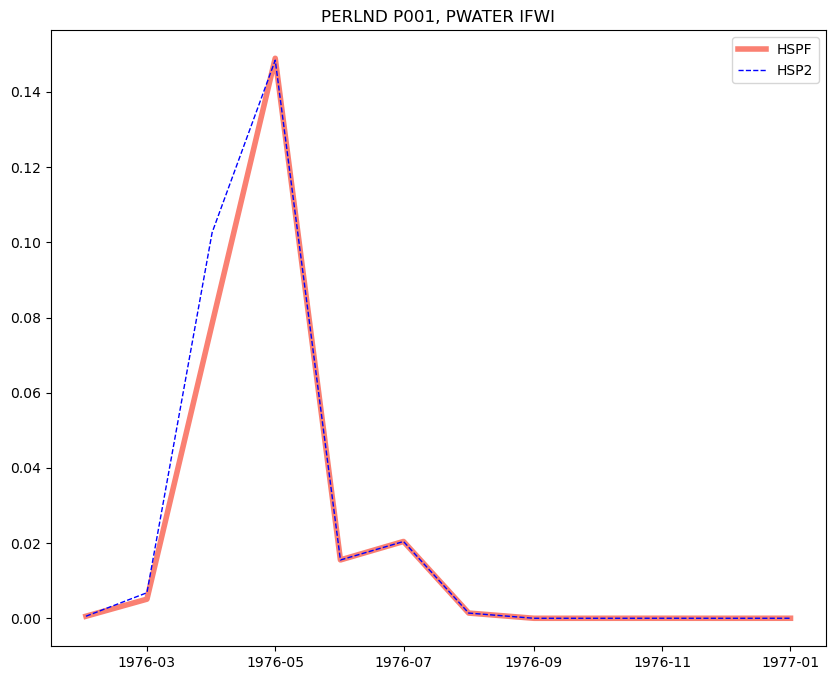

In [43]:
plot("PERLND", pls, "PWATER", "IFWI", "sum")

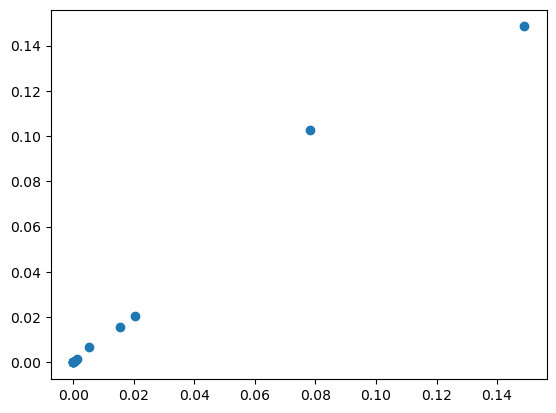

In [44]:
scatter("PERLND", pls, "PWATER", "IFWI", "sum")

#### PERLND PWATER IFWO

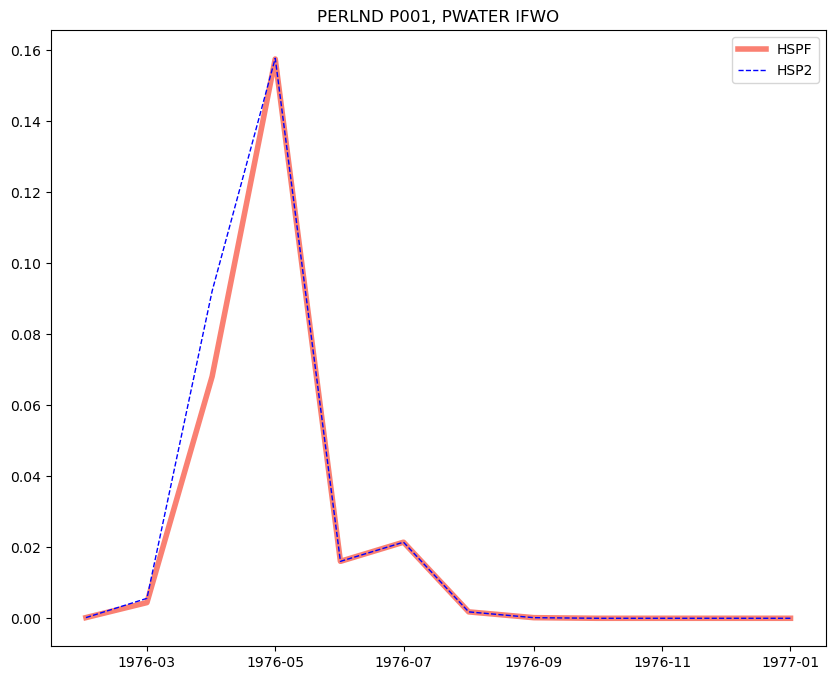

In [45]:
plot("PERLND", pls, "PWATER", "IFWO", "sum")

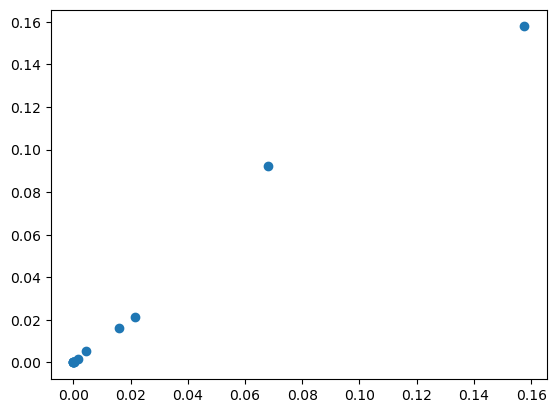

In [46]:
scatter("PERLND", pls, "PWATER", "IFWO", "sum")

#### PERLND PWATER IGWI

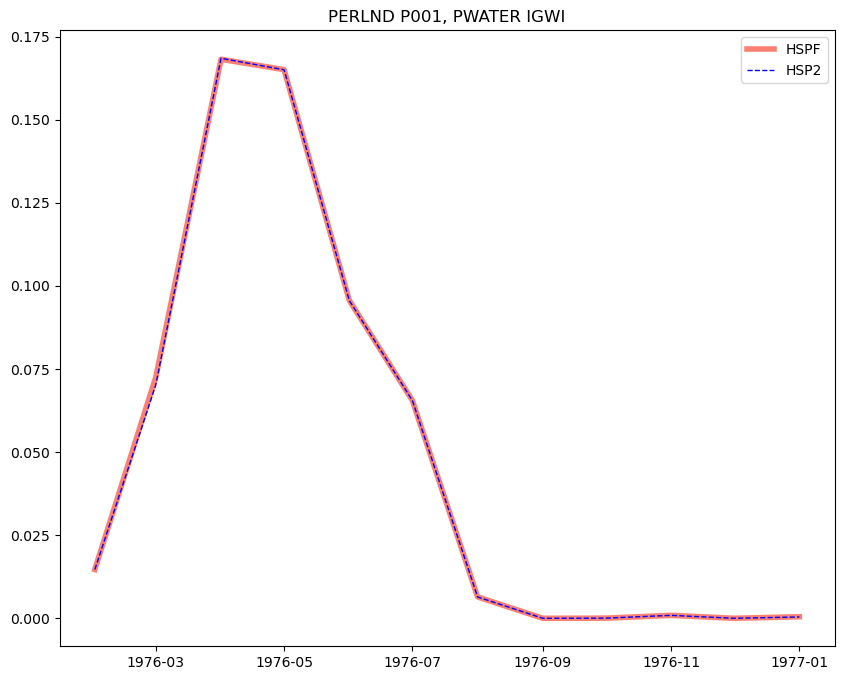

In [47]:
plot("PERLND", pls, "PWATER", "IGWI", "sum")

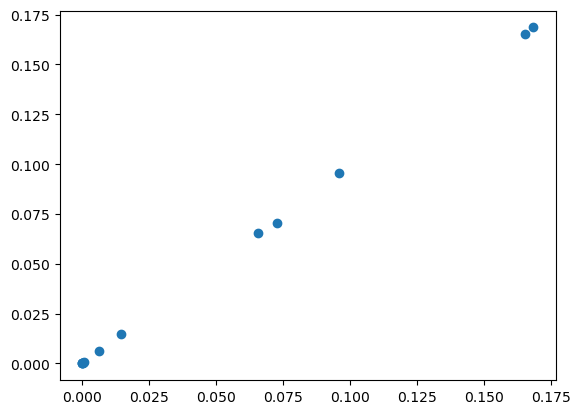

In [48]:
scatter("PERLND", pls, "PWATER", "IGWI", "sum")

#### PERLND PWATER INFIL

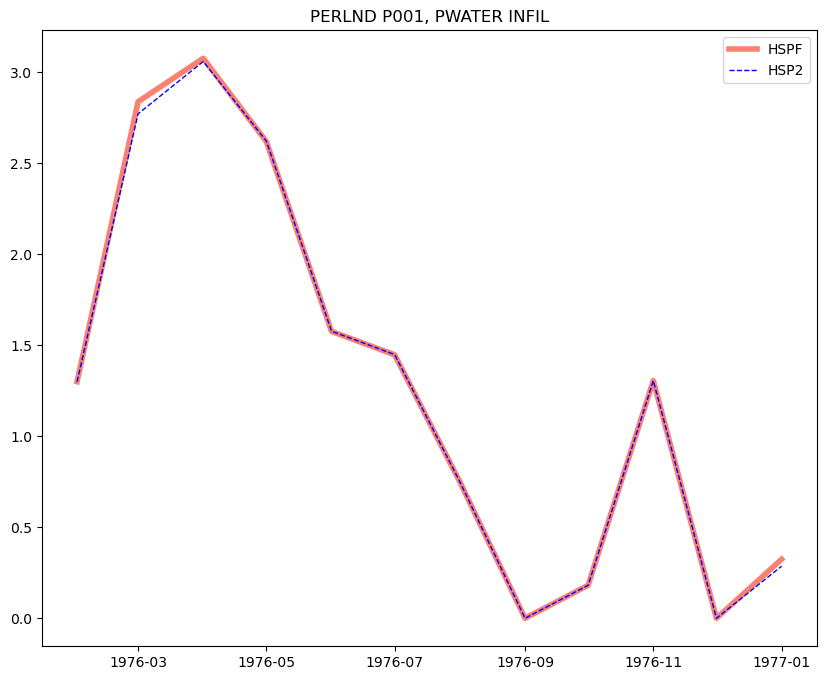

In [49]:
plot("PERLND", pls, "PWATER", "INFIL", "sum")

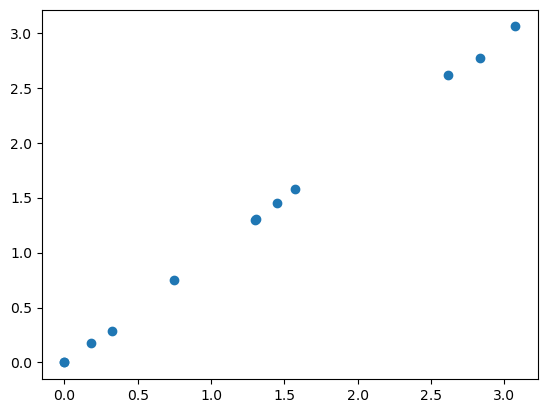

In [50]:
scatter("PERLND", pls, "PWATER", "INFIL", "sum")

#### PERLND PWATER LZET

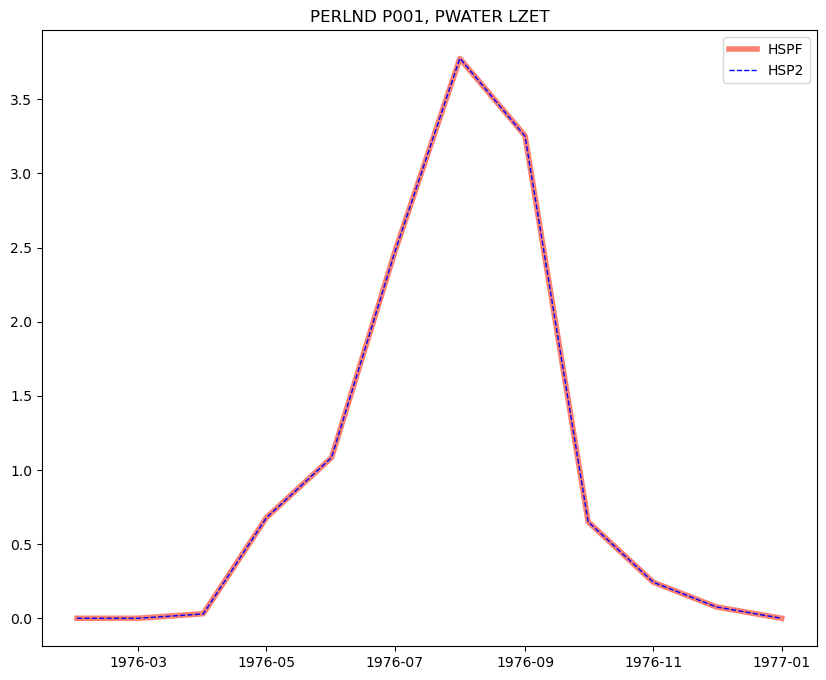

In [51]:
plot("PERLND", pls, "PWATER", "LZET", "sum")

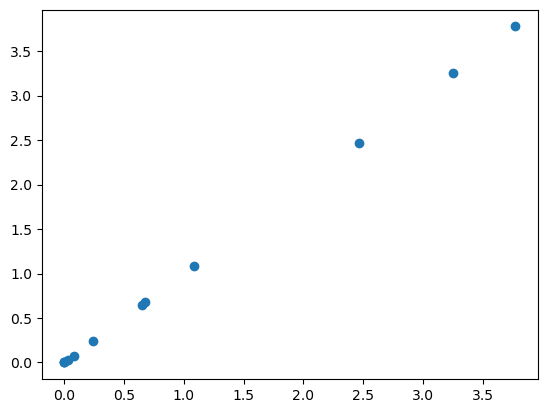

In [52]:
scatter("PERLND", pls, "PWATER", "LZET", "sum")

#### PERLND PWATER PERC

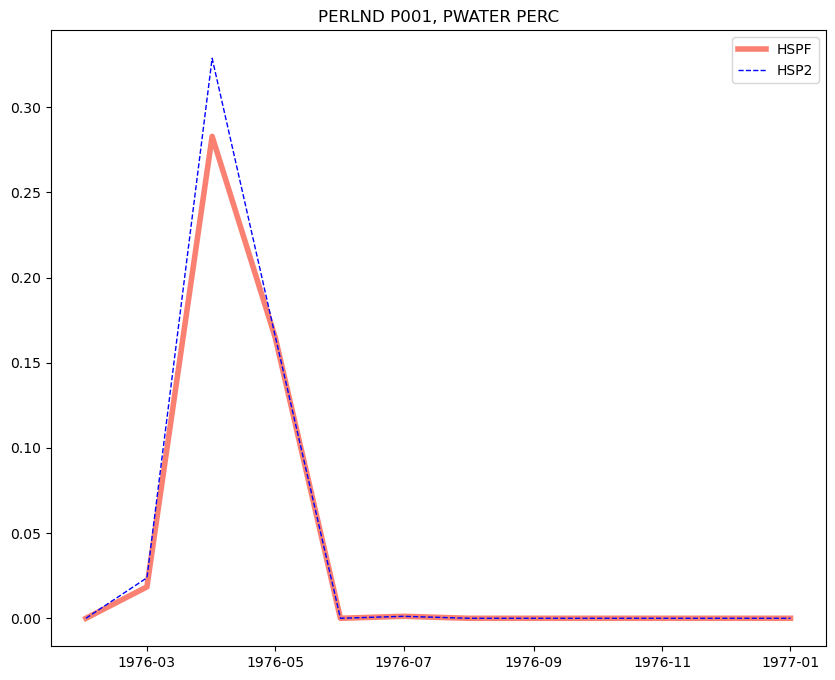

In [53]:
plot("PERLND", pls, "PWATER", "PERC", "sum")

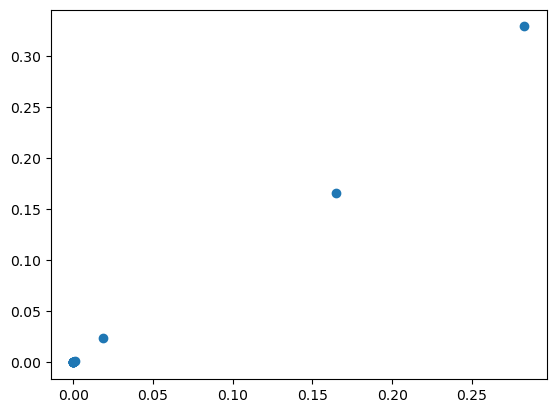

In [54]:
scatter("PERLND", pls, "PWATER", "PERC", "sum")

#### PERLND PWATER PERO

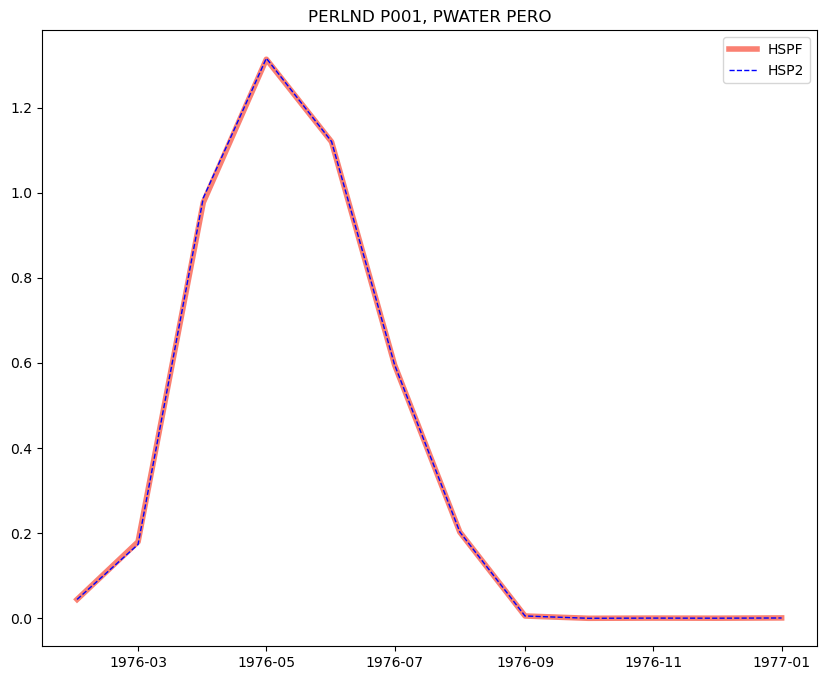

In [55]:
plot("PERLND", pls, "PWATER", "PERO", "sum")

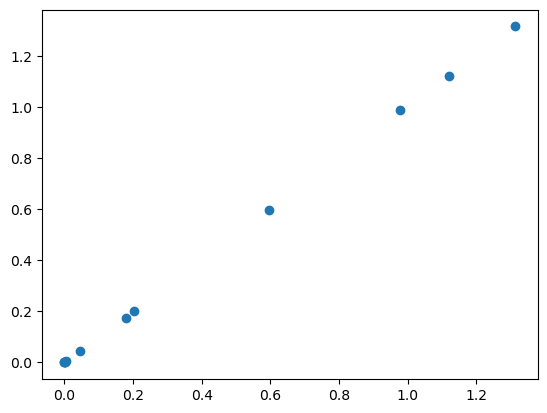

In [56]:
scatter("PERLND", pls, "PWATER", "PERO", "sum")

#### PERLND PWATER PERS

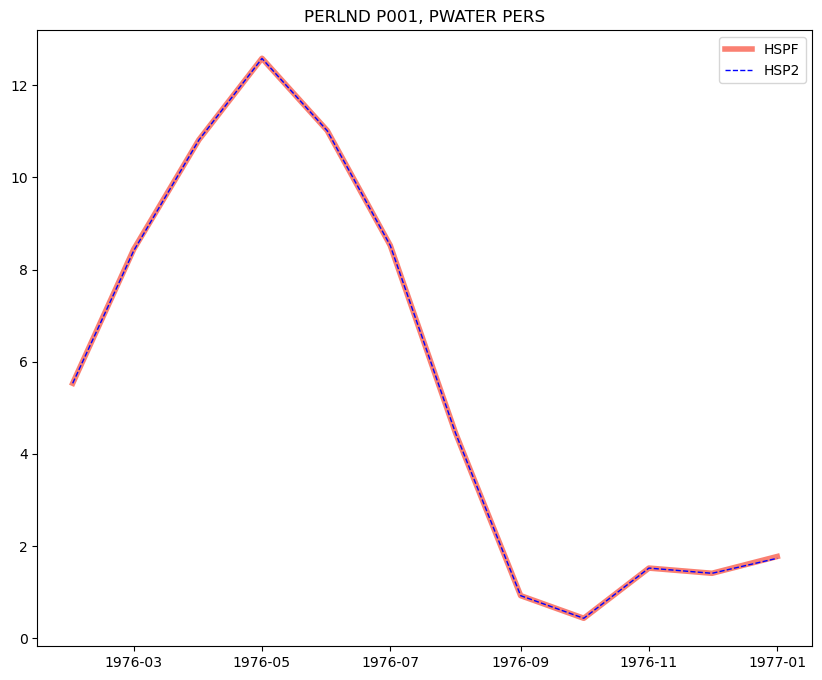

In [57]:
plot("PERLND", pls, "PWATER", "PERS", "last")

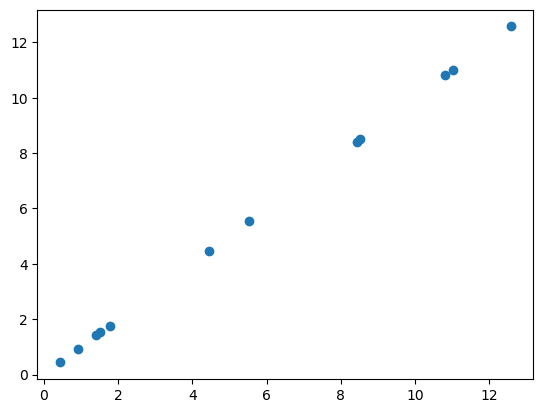

In [58]:
scatter("PERLND", pls, "PWATER", "PERS", "last")

#### PERLND PWATER PET, Monthly

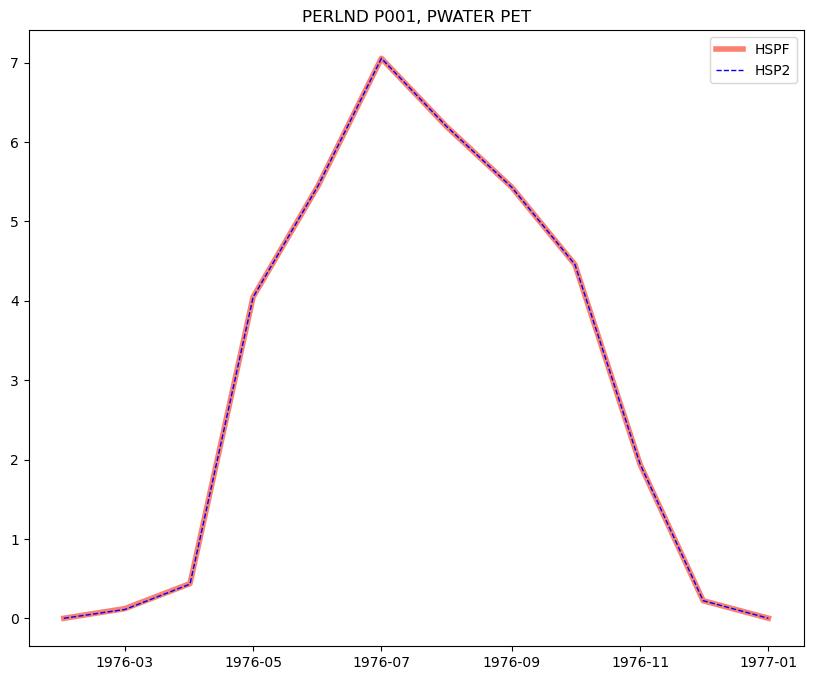

In [59]:
plot("PERLND", pls, "PWATER", "PET", "sum")

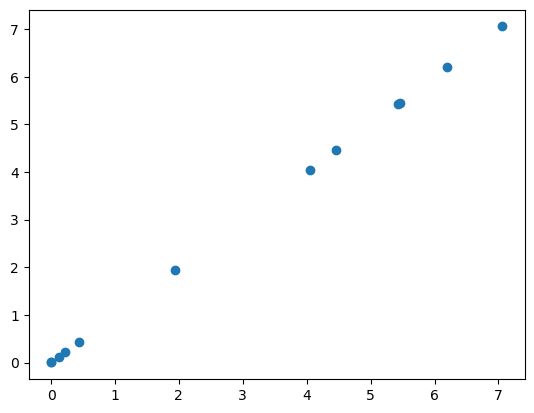

In [60]:
scatter("PERLND", pls, "PWATER", "PET", "sum")

#### PERLND PWATER SUPY

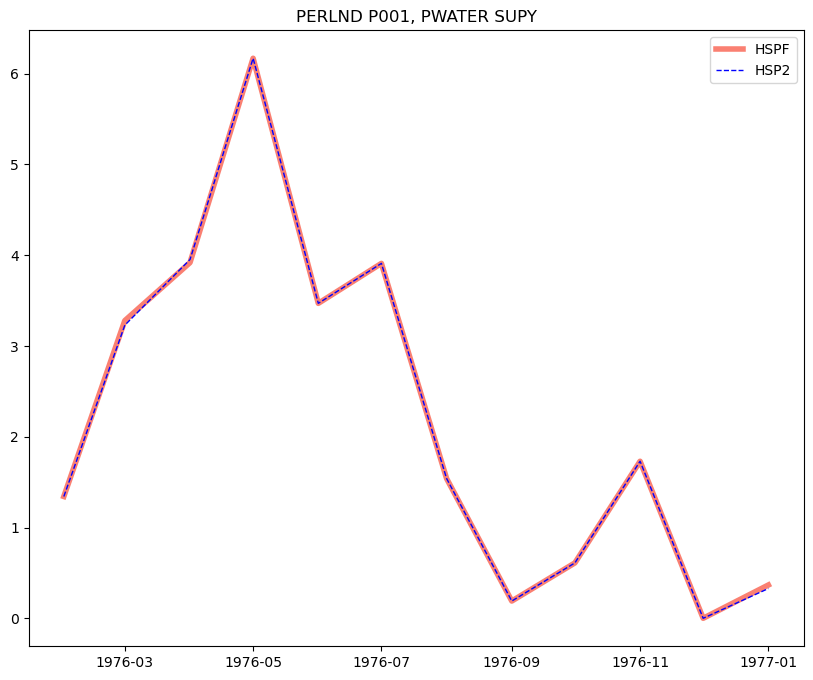

In [61]:
plot("PERLND", pls, "PWATER", "SUPY", "sum")

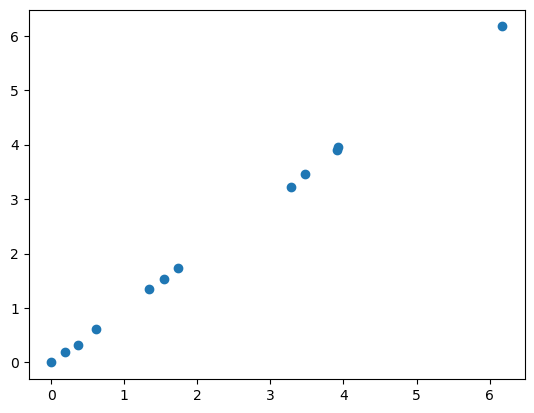

In [62]:
scatter("PERLND", pls, "PWATER", "SUPY", "sum")

#### PERLND PWATER SURO

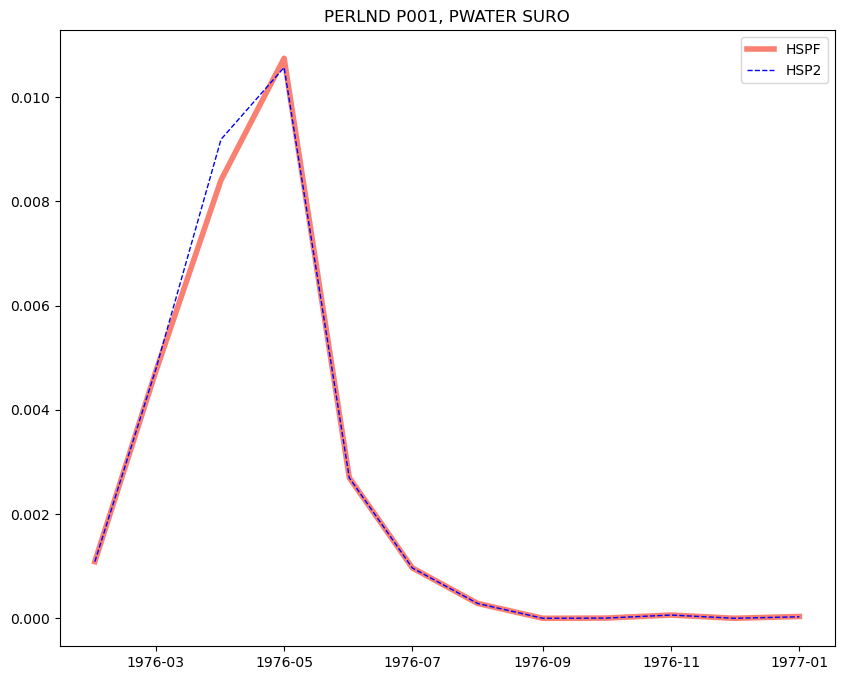

In [63]:
plot("PERLND", pls, "PWATER", "SURO", "sum")

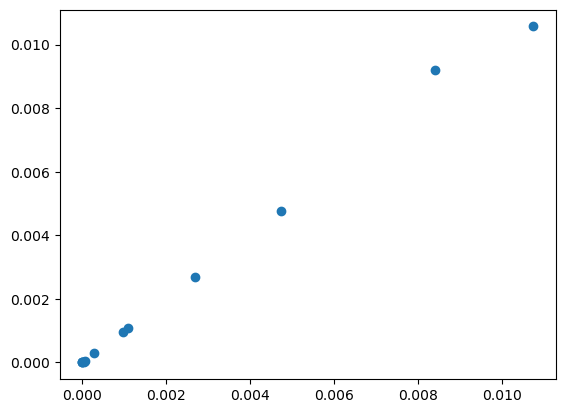

In [64]:
scatter("PERLND", pls, "PWATER", "SURO", "sum")

#### PERLND PWATER TAET

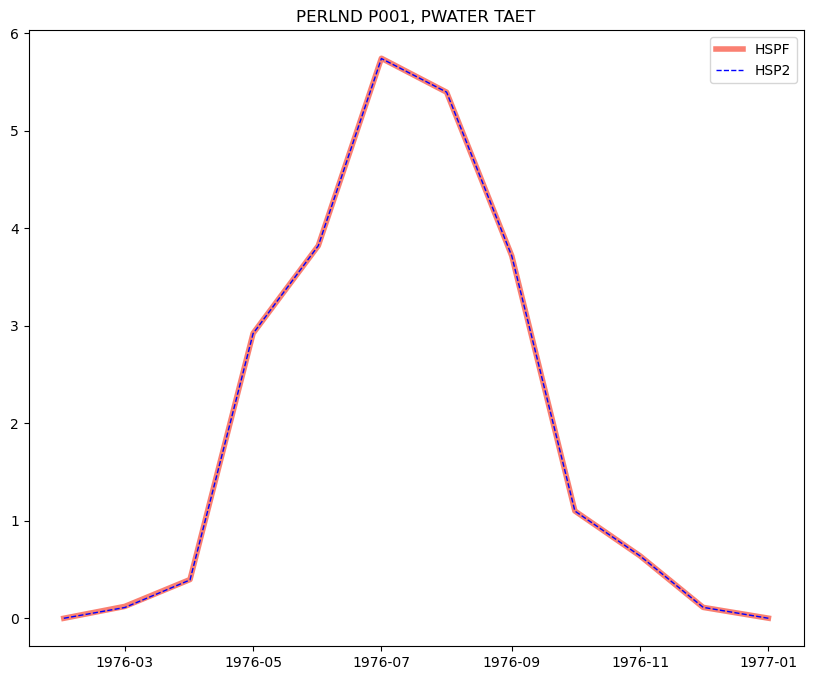

In [65]:
plot("PERLND", pls, "PWATER", "TAET", "sum")

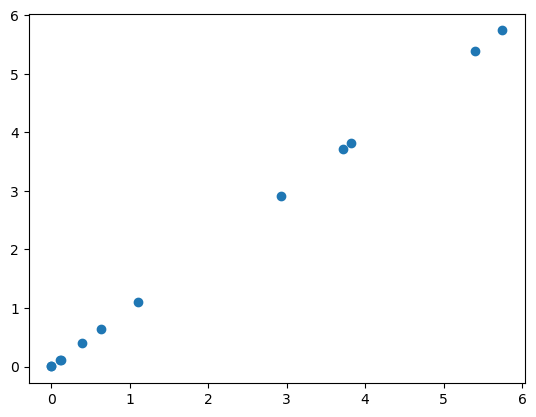

In [66]:
scatter("PERLND", pls, "PWATER", "TAET", "sum")

#### PERLND PWATER UZET

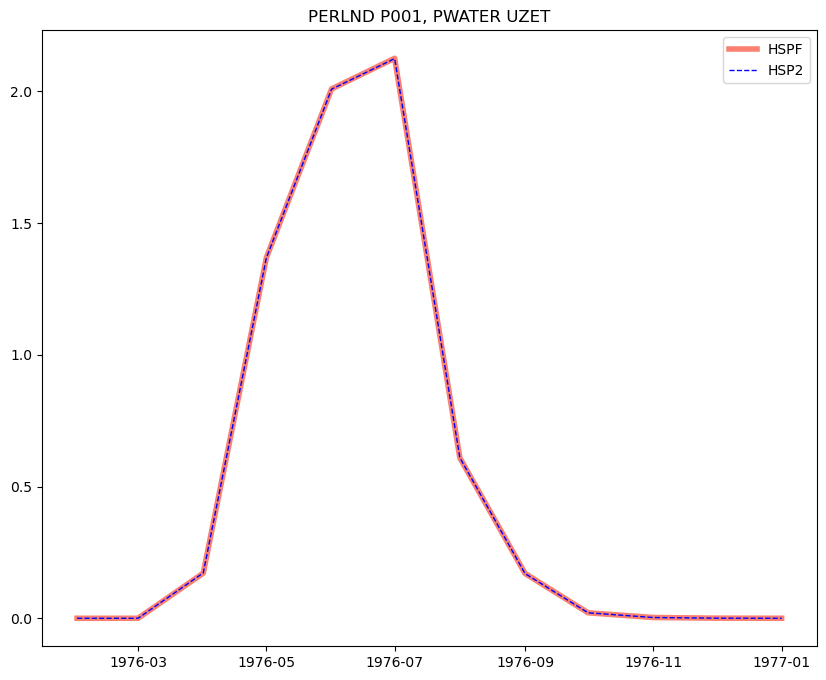

In [67]:
plot("PERLND", pls, "PWATER", "UZET", "sum")

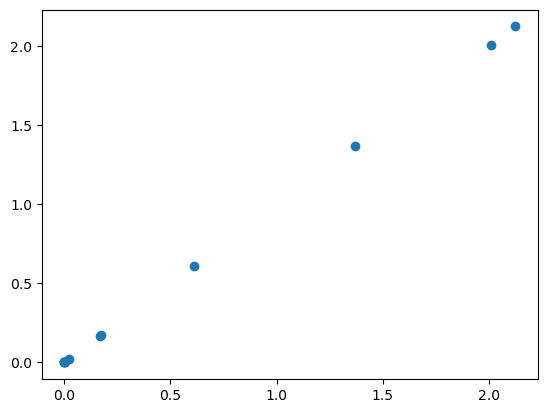

In [68]:
scatter("PERLND", pls, "PWATER", "UZET", "sum")

#### PERLND PWATER UZI

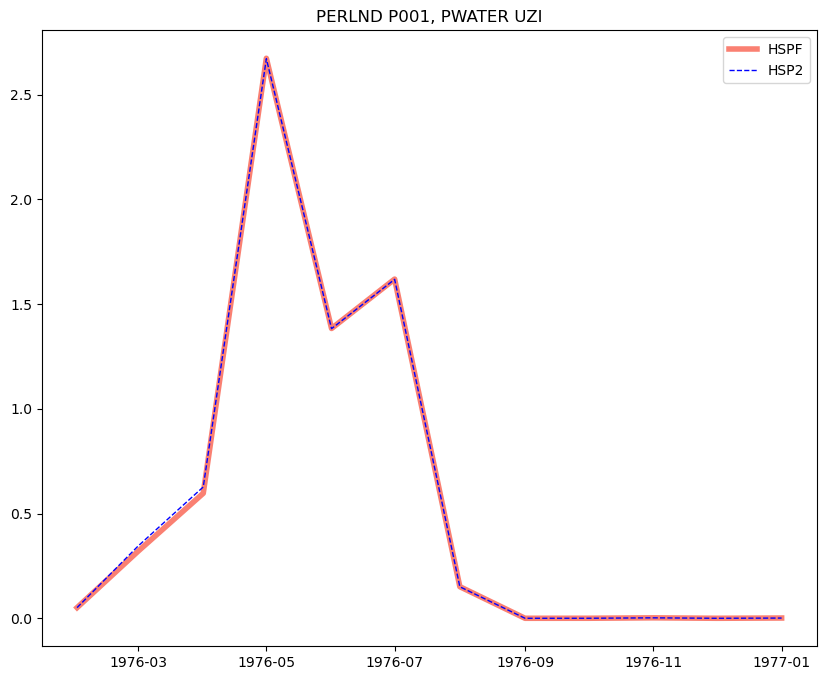

In [69]:
plot("PERLND", pls, "PWATER", "UZI", "sum")

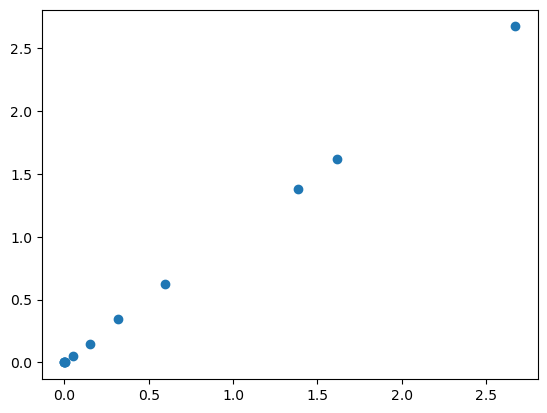

In [70]:
scatter("PERLND", pls, "PWATER", "UZI", "sum")